# 📈  Calculating and Graphing the Term Structure of Interest Rates
<br>



<div style="display: flex; flex-wrap: wrap; align-items: center; gap: 15px; margin-bottom: 25px; padding-bottom: 15px; border-bottom: 1px solid #eaeaea;">
  
  <a href="https://colab.research.google.com/github/PatrickJHess/Volume-Three-Chapter-One/blob/master/colab/Colab_Calculating_And_Graphing_The_Term_Structure_Of_Interest_Rates.ipynb" target="_blank" style="display: flex; align-items: center;">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" style="height: 28px; margin: 0;">
  </a>
&emsp;
  <a href="https://mybinder.org/v2/gh/PatrickJHess/Volume-Three-Chapter-One/master?urlpath=lab/tree/notebooks/Calculating_And_Graphing_The_Term_Structure_Of_Interest_Rates.ipynb" target="_blank" style="background-color: #f5a252; color: white; padding: 0 12px; text-decoration: none; font-weight: bold; border-radius: 4px; font-family: sans-serif; display: flex; align-items: center; font-size: 0.9em; height: 28px; box-sizing: border-box;">
    <span style="margin-right: 6px; font-size: 1.1em;">🚀</span> Launch Live in Binder
  </a>
&emsp;
  <a href="https://patrickjhess.github.io/Volume-Three-Chapter-One/" style="background-color: #f1f3f4; color: #3c4043; border: 1px solid #dadce0; padding: 0 12px; text-decoration: none; font-weight: bold; border-radius: 4px; font-family: sans-serif; display: flex; align-items: center; font-size: 0.9em; height: 28px; box-sizing: border-box;">
    <span style="margin-right: 6px; font-size: 1.1em;">⬅️</span> Return to Main Book
  </a>

</div>

<details>
<summary><b>🤔 Notebook Setup: Why the "Try/Except" Imports?</b></summary>

**The Goal:**
To ensure this notebook runs perfectly whether you are using **Google Colab**, a local **Jupyter instance**, or a remote server without you having to manually install software.

**Key Concepts in this Section:**
*   **Standard Libraries:** Modules like `os`, `sys`, and `datetime` come "in the box" with Python. We use them for system tasks and date math.
*   **External Libraries:** NumPy and Pandas are the "heavy hitters" for data. They aren't always installed by default.
*   **The `try/except` Logic:** This is a safety net.
    1. We **try** to import the library.
    2. If it fails (because it's not installed), the **except** block triggers a `!pip install` to download it automatically.
*   **Aliasing (`as np`):** We rename `numpy` to `np` to save keystrokes. In professional finance code, `np` and `pd` are the universal shorthand.

</details>

## 🛠️ Preparing the Notebook

<details>
<summary><b>👉 Click to Expand: 📦 Importing Libraries, Modules, and Functions</b></summary>

As a best practice, we always begin by importing our necessary dependencies in the very first code cell. Notice how lightweight our imports are here: just the built-in `request` module and the `pandas` and `numpy` libraries. ✨

This simplicity is a direct result of using the `financial_quant` package, which handles the heavy lifting behind the scenes. 🏗️ By keeping complicated setup details out of sight, we ensure the spotlight remains focused exactly where it belongs—on the core analysis. 🎯

```python

import requests

try:
    import numpy as np
except:
    !pip install numpy
    import numpy as np
try:
    import pandas as pd
except:
    !pip install pandas
    import pandas as pd
```
**👀 Keep an eye out**: As we progress, pay attention to how the `financial_quant` package is imported as `fq`, and how every reference to its functions begins with fq.. 💡 This follows the exact same standard practice as NumPy (np) and Pandas (pd).

</details>

In [2]:


try:
    import numpy as np
except:
    !pip install numpy
    import numpy as np
try:
    import pandas as pd
except:
    !pip install pandas
    import pandas as pd

## 📦 Getting Functions from financial_quant package

<details>
<summary><b style="font-size:1.2em; color: #1976d2; cursor: pointer;">🔌 Dynamic Verification: How Remote Version Checking Works</b></summary>
<br>
<p><b>The Logic:</b><br>
Instead of blindly reinstalling packages or guessing if our local tools are up to date, we are dynamically reaching out to GitHub to inspect the live code. By scanning the remote file on the fly, the notebook can verify exactly which version of the quantitative toolkit is currently published before we use it.</p>

<p><b>The Workflow:</b></p>

<ol>
<li><b>Request:</b> The code acts like an automated web browser. It uses Python's `urllib` to visit the GitHub URL and request the raw text of the Python script.</li>
<li><b>Decode:</b> The internet sends data back as raw bytes (1s and 0s). We use `.decode('utf-8')` to translate that raw data into a readable Python string.</li>
<li><b>Search & Extract:</b> We use a Regular Expression (`regex`) to scan the document, pinpointing the exact line where the version is declared and extracting the number.</li>
<li><b>Verify:</b> The notebook compares this remote version against your local installation to ensure you have the latest financial models. </li>
<li><b>Import & Route:</b> Once verified, we `import financial_quant as fq`. Behind the scenes, an `__init__.py` file routes the complex tools from deeply nested folders up to the surface.</li>
<li><b>Execute:</b> You can now confidently type `fq.one_y_axis()` or `fq.calc_ytm()`, knowing you are running the most up-to-date code.</li>
</ol>

<p><b>Why do this?</b><br>
It makes your notebooks highly intelligent. Rather than relying on static installations, the notebook becomes self-aware—it can check if its math models are perfectly synced with the master branch and alert you if a critical update is missing. It is a lightweight way to guarantee reproducibility without cluttering the environment.</p>
</details>

In [2]:
# Use Python's built-in urllib to fetch the remote setup script
import urllib.request

# Download, decode, and execute the updater script directly from GitHub
updater_url = "https://raw.githubusercontent.com/PatrickJHess/quant_repo/master/fq_updater.py"
exec(urllib.request.urlopen(updater_url).read().decode('utf-8'))

# Run the installer/updater function and alias the package as 'fq'
fq = import_financial_quant()

✅ 'financial_quant' is up to date (Version 1.0.2).


## 📈  Term Structure: Putting NumPy and Pandas to Work
    
The *term structure of interest rates* (term structure) describes how interest rates vary over time. It’s a critical financial metric reflected in the pricing or valuation of almost all assets.

NumPy and Pandas are powerful tools that greatly simplify the manipulation and calculation of extensive and complex financial data. In this section, we’ll explore their application in calculating the term structure on various dates, a process that requires accessing large datasets and performing numerous calculations.

### 🧮 Calculating term structure

The earlier discussion of bond pricing described the price of a zero-coupon bond as its maturity value multiplied by the present-value factor. A NumPy array and a Pandas DataFrame included interest rates, future values, and present-value factors. These same concepts are used to calculate term structure.

### 📍 Spot rates of interest

Put simply, term structure is the relation between the annualized interest rates of zero-coupon bonds, or the *spot rate* of interest, and the bonds’ maturities. The price of a zero-coupon bond with a maturity of $t$ and a principal of \$1 is

$$ P(t) = e^{ -r_t\times t}$$

The annualized continuously-compounded interest rate of the $t$-period zero-coupon bond is:


$$r_t = \frac{-ln(P(t))}{t}$$

with $r_t$ representing the spot rate of interest for $t$ periods. As such, if a zero-coupon bond pays \$1 in six months and has a price of \$0.9753, the spot rate of interest is:

$$5\% = \frac{-ln(0.9753)}{0.5}$$

The spot rate reflects a return that begins immediately for a specific period of time. To consider future periods, we turn to *forward rates*.



### ↻ ◁ || ▷ Forward rates of interest
The forward rate of interest represents the additional return gained by extending an investment’s duration&mdash;or the extra earnings from investing for two months instead of one, for example. When two bonds offer an identical single payment at maturity, the forward rate between the shorter and longer maturities is determined by the ratio of their respective prices.

For zero-coupon bonds with a principal of $1, the calculation of one plus the forward rate between $t$ and $t+\Delta t$ is:

$$\frac{ \frac{1}{P(t+\Delta t)}}{ \frac{1}{P(t)}}= e^{f(t,t+\Delta t)\times\Delta t}$$

simplified to:

$$\frac{P(t)}{P(t+\Delta t)}= e^{f(t,t+\Delta t)\times\Delta t}$$

The continuously-compounded annualized forward rate between $t$ and $t+\Delta t$ is:

$$f(t,t+\Delta t) = \frac{\ln(P(t)) - \ln(P(t+\Delta t))}{\Delta t}$$

The forward rates can be locked in by purchasing a zero-coupon bond that matures in $t+\Delta t$ periods and for $t$ periods, borrowing $P(t+\Delta t)$ today at the rate $P(t)^{-1}$. At $t$, the borrowing is repaid, and at $t + \Delta t$, the zero-coupon bond matures and pays $1. The borrowing, repayment, and locked-in rate-of-return calculations are shown below:

$$\text{Amount Borrowed} = P(t+\Delta t)$$
$$\text{Repayment} = P(t+\Delta t) \times \frac{1}{P(t)}$$
$$\text{Locked-In Rate of Return} = \frac{1}{\frac{P(t+\Delta t)}{P(t)}}-1 = \frac{P(t)}{P(t+\Delta t)}-1$$

The continuously-compounded annualized locked-in rate of return equals:

$$\frac{\ln(P(t)) - \ln(P(t+\Delta t))}{\Delta t}$$

This value is the same as the continuously-compounded forward rate of interest between $t$ and $t+\Delta t$.



Although it might seem obvious that the locked-in rate of return and the forward rate are equal, this result is significant. Imagine an investor who intends to invest at the future date $t$ for $\Delta t$ periods. The investor can:

1. Wait until $t$ to invest at the unknown spot rate $r(t,t+\Delta t)$, or
2. Lock in a rate of return today that equals the current forward rate $f(t,t+\Delta t)$.

In a state of equilibrium, the prices of zero-coupon bonds ensure that investors are indifferent to either securing a spot rate immediately or deferring investment until a future, unknown spot rate. Similar to the odds in a sports wager, the forward rate represents a "fair-bet" value for these future unknown spot rates. Forward rates forecast future spot rates, but that's not the same as equaling the expected values.

---
<div style="display:block; border-left: 8px solid #00bcd4; padding: 20px; background-color: #f0fbfc; border-radius: 0 8px 8px 0; margin: 20px 0;">

  <h3 style="margin-top: 0; color: #00838f;">✨ AI Mode: The Forward Rate "Fair Bet" Analysis</h3>
  
  <p><strong>The Concept:</strong> You've just derived that the forward rate is the "no-arbitrage" rate that makes an investor indifferent between a long-term bond and rolling over short-term bonds. But does the market <em>actually</em> believe the forward rate is a perfect forecast?</p>
  
  <p><strong>Research Task:</strong> Use the prompt below in your AI research tool to analyze today's yield curve dynamics:</p>
  
  <blockquote style="border-left: 4px solid #80deea; padding: 10px 15px; margin: 15px 0; color: #006064; background-color: #e0f7fa; border-radius: 4px;">
    <strong>AI Prompt:</strong> <em>"Analyze the current 2026 US Treasury yield curve. Compare the 1-year forward rate starting 2 years from now ($f_{2,3}$) against consensus forecasts for the Fed Funds Rate in 2028. Based on the <strong>Liquidity Preference Theory</strong>, explain why the forward rate might be overestimating the future spot rate."</em>
  </blockquote>
  
  <p><strong><a href="https://www.google.com/search?q=current+US+Treasury+forward+rates+vs+expectations+hypothesis+2026+analysis" target="_blank" style="text-decoration: none; color: #00838f;">Explore via Google AI Search ↗</a></strong></p>

</div>

<details>
  <summary style="cursor: pointer;">
    <h2><font size="5">💡 <b><font color="#283593">SECTION SUMMARY</font></font></h2></b>
  </summary>
  <hr style="border: 1px solid #283593; margin-top: 5px; margin-bottom: 15px;">
  <blockquote style="color: #212121; font-family: sans-serif; font-size: 1.1em; line-height: 1.6;">
    This upcoming section bridges foundational financial theory with practical Python programming by demonstrating how to analyze the term structure of interest rates using Treasury bills (T-bills). It serves as a practical guide for extracting and manipulating real-world financial data.<br><br>
    <font color="#283593" size="4"><b>Key topics covered include:</b></font>
    <ul style="margin-top: 10px; margin-bottom: 15px;">
      <li style="margin-bottom: 10px;"><b>Core Financial Concepts:</b> An introduction to T-bills—short-term securities that make a single principal payment at maturity—and why they are priced based on single spot rates. It also highlights the term structure of interest rates as a vital economic indicator that reflects past, present, and future market conditions.</li>
      <li style="margin-bottom: 10px;"><b>Importing Financial Data:</b> A practical walkthrough of using the Pandas library to fetch data directly from the web. You will learn how to use the <code>read_excel()</code> method to seamlessly convert an online Excel workbook into a usable Pandas DataFrame.</li>
      <li style="margin-bottom: 0;"><b>Data Manipulation and Retrieval:</b> A detailed look at how to navigate your newly created DataFrames. The section explains how to pinpoint and extract specific rows of data using Pandas indexing tools, specifically the <code>.loc</code> (label-based) and <code>.iloc</code> (integer-based) attributes, as well as the <code>.get_indexer()</code> method for handling missing values gracefully.</li>
    </ul>
    <i>By the end of this section, you will understand both the economic significance of T-bill term structures and the essential Python data-wrangling techniques required to access and analyze them effectively.</i>
  </blockquote>
</details>

## 🏛️ Calculating the Term Structure of Interest Rates with Treasury Bills
Treasury bills, or T-bills, mature in a year or less and make a single principal payment at maturity. In this section, we’ll apply the Python concepts we’ve learned so far to T-bill data, using the bills to demonstrate the term structure between one month and one year. Because the bills make a single payment, their prices are determined by the single spot rate of interest at maturity.

## 🚀 Python and finance in action

This example will outline two Python concepts integral to financial calculations. First, it will demonstrate how to leverage the Pandas library to access Excel workbooks from a URL and convert them into DataFrames&mdash;a highly effective skill given Excel’s widespread use in the finance world. The Pandas method we’ll use is `read_excel` (see [Pandas and Excel](https://patrickjhess.github.io/Introduction-To-Python-For-Financial-Python/An_Introduction_To_Pandas.html#dataframes-csv-and-excel-files)). Second, this example will illustrate the valuable data manipulation techniques available through Pandas, specifically focusing on how the attributes `loc` and `iloc` and the method `get_indexer` are used to retrieve the necessary data for calculations (see [Use getindexer to access data](ttps://patrickjhess.github.io/Introduction-To-Python-For-Financial-Python/An_Introduction_To_Pandas.html#the-loc-and-iloc-attributes))

Measuring the term structure is a key financial skill. The term structure of interest rates is a critical indicator of financial market conditions. Its explanation, along with the concepts necessary for its calculation, represents the most significant aspect of this example. The relationships between past, present,and future market conditions are all expressed by measuring the term structure.

## Getting T-bill data

T-bill data is available from the US Department of the Treasury (Treasury) at the department’s [Daily Treasury Bill Rate page](https://home.treasury.gov/resource-center/data-chart-center/interest-rates/TextView?type=daily_treasury_bill_rates&field_tdr_date_value_month=202409). The data used in this example is for September 2022 and was uploaded to the authors’ Dropbox as an Excel workbook.

### Accessing the data

The Pandas magic used to read an Excel workbook from a URL is `read_excel()`. The arguments of the method are:



1.    The website address, or `url`. This argument is a required item
2.   The columns used as the index, or `index_col`. This argument is optional and is assigned to the `Date` column.


The below code assigns the Dropbox URL to `url` and sets `index_col` to `Date`, then passes both through our `read_excel()` method to give us `Tbill_data_excel`.


```
url='https://www.dropbox.com/scl/fi/wdb24k0dddkpq7qry5sl8/\
daily-treasury-rates-9-22.xlsx?rlkey=qxoo8vpa4iziu5kvi27u6c41l&dl=1'
Tbill_data_excel=pd.read_excel(url, index_col='Date')
```


## 📗 Creating a DataFrame from an Excel file 📊

Let’s now turn this snippet into useable code. In the following code cell, an Excel workbook is accessed from Dropbox, which provides the URL. The Pandas method `read_excel()` is used to read and assign the data to `Tbill_data_excel`. The `Date` column is assigned as the index. Notice here that `try` and `except` are used to alert us if the file is not available.


In [4]:
#The full file path.
url='https://www.dropbox.com/scl/fi/wdb24k0dddkpq7qry5sl8/\
daily-treasury-rates-9-22.xlsx?rlkey=qxoo8vpa4iziu5kvi27u6c41l&dl=1'
print(f"Attempting to load data from: {url}")

#Load the data from Excel, using the Date column as the index.
try:
    Tbill_data_excel = pd.read_excel(url, index_col='Date')

    # Display the loaded DataFrame to verify it worked.
    display(Tbill_data_excel.head())

except FileNotFoundError:
    print("\nERROR: File not found.")
    print("Please check that the 'URL' address")

Attempting to load data from: https://www.dropbox.com/scl/fi/wdb24k0dddkpq7qry5sl8/daily-treasury-rates-9-22.xlsx?rlkey=qxoo8vpa4iziu5kvi27u6c41l&dl=1


,4 WEEKS BANK DISCOUNT,4 WEEKS COUPON EQUIVALENT,8 WEEKS BANK DISCOUNT,8 WEEKS COUPON EQUIVALENT,13 WEEKS BANK DISCOUNT,13 WEEKS COUPON EQUIVALENT,26 WEEKS BANK DISCOUNT,26 WEEKS COUPON EQUIVALENT,52 WEEKS BANK DISCOUNT,52 WEEKS COUPON EQUIVALENT
Date,,,,,,,,,,
2022-09-30,2.70,2.74,3.07,3.13,3.22,3.29,3.82,3.95,3.87,4.03
2022-09-29,2.68,2.72,3.08,3.14,3.26,3.33,3.78,3.91,3.80,3.96
2022-09-28,2.50,2.54,2.96,3.01,3.29,3.36,3.78,3.91,3.81,3.97
2022-09-27,2.60,2.64,2.99,3.05,3.26,3.33,3.83,3.96,3.97,4.14
2022-09-26,2.64,2.68,2.99,3.05,3.30,3.37,3.87,4.00,3.98,4.15


## 🐼 Accessing rows of a Pandas DataFrame 🔍

We’ve now created a DataFrame, but we still need to access its contents. Three common ways of accessing the rows of a DataFrame are the attributes `loc` (as in “location”) and `iloc` (as in “integer location”) and the method `get_indexer()`. All three ways access rows by the value of the index.

The `loc` attribute of a DataFrame accesses a row by using its index value. In the below code, the specific value of the index `'09/15/2022'` is accessed. If the value is not in the index, an error is returned via `except`. There are only 30 days in September, so `'09/31/2022'` fails and the message `'Value Not in Index'` is displayed.



```
try:
  display(Tbill_data_excel.loc['09/15/2022'])
except:
  display('Value Not in Index')
try:
  display(Tbill_data_excel.loc['09/31/2022'])
except:
  display('Value Not in Index')
```



In [5]:
try:
  display(Tbill_data_excel.loc['09/15/2022'])
except:
  display('Value Not in Index')
try:
  display(Tbill_data_excel.loc['09/31/2022'])
except:
  display('Value Not in Index')

4 WEEKS BANK DISCOUNT         2.68
4 WEEKS COUPON EQUIVALENT     2.72
8 WEEKS BANK DISCOUNT         2.92
8 WEEKS COUPON EQUIVALENT     2.97
13 WEEKS BANK DISCOUNT        3.12
13 WEEKS COUPON EQUIVALENT    3.19
26 WEEKS BANK DISCOUNT        3.69
26 WEEKS COUPON EQUIVALENT    3.81
52 WEEKS BANK DISCOUNT        3.83
52 WEEKS COUPON EQUIVALENT    4.00
Name: 2022-09-15 00:00:00, dtype: float64

'Value Not in Index'

<hr>



The `iloc` attribute accesses a row by its indexed integer value. In this case, the `Date` column "09/15/2022" has an index value of 11. If the integer value is not present, an error is returned, as in the earlier code. The DataFrame has 21 rows, and so the index value of 45 fails, as shown below.  


```
try:
  display(Tbill_data_excel.iloc[11])
except:
  display('Value Not in Index')
try:
  display(Tbill_data_excel.loc[45'])
except:
  display('Value Not in Index')
```





<hr>

In [6]:
try:
  display(Tbill_data_excel.iloc[11])
except:
  display('Value Not in Index')
try:
  display(Tbill_data_excel.iloc[45])
except:
  display('Value Not in Index')

4 WEEKS BANK DISCOUNT         2.68
4 WEEKS COUPON EQUIVALENT     2.72
8 WEEKS BANK DISCOUNT         2.92
8 WEEKS COUPON EQUIVALENT     2.97
13 WEEKS BANK DISCOUNT        3.12
13 WEEKS COUPON EQUIVALENT    3.19
26 WEEKS BANK DISCOUNT        3.69
26 WEEKS COUPON EQUIVALENT    3.81
52 WEEKS BANK DISCOUNT        3.83
52 WEEKS COUPON EQUIVALENT    4.00
Name: 2022-09-15 00:00:00, dtype: float64

'Value Not in Index'

<hr>


    
Rounding out our Pandas tools, the method `get_indexer()` returns the indexed integer values for a specific value of the index as an array. In the below example, an array with a single value is returned. For the Date "09/15/2022" the value 11 is returned. The `get_indexer()` method returns −1 for missing values, which avoids interrupting the code.



```
displayT(bill_data_excel.index.get_indexer(['09/15/2022'])
displayT(bill_data_excel.index.get_indexer(['09/31/2022'])
```




<hr>

In [7]:
#return row number for date '09/15/2022'
display(Tbill_data_excel.index.get_indexer(['09/15/2022']))
#September has only 30 days, value of -1 returned
display(Tbill_data_excel.index.get_indexer(['09/31/2022']))

array([11])

array([-1])

## 🔢 Calculating the Term Structure: 🔙 A Return

Having gathered the bond data, we can return to calculating the term structure. Recall that the price of a T-bill (a zero-coupon bond) is its principal discounted back at the annualized continuous spot rate of interest. The forward rate of interest is the difference of the natural logs of the prices of a shorter maturity and a longer maturity zero-coupon bond. To calculate the term structure, we need to first calculate the prices of the T-bills (the zero-coupon prices).


T-bills are quoted as bank discounts or coupon-equivalent yields.

$$C Bill\,Price = 100 - bank\,discount\times\frac{Maturity\,In\,Days}{360}$$

The bank discount of the four-week bill on September 15th is 2.68%, which implies a bill price of:

$$ 99.792 = 100 - 2.68\times\frac{28}{360}$$

The coupon equivalent is the annualized rate of return that is calculated with the convention of *365 days* per year. The calculation is the actual rate of return (the gain on the bill divided by the bill price) multiplied by 365 divided by the maturity of the bill in days. A four-week bill matures in 28 days, and its coupon equivalent is:

$$  Coupon\,Equivalent =\frac{100 - Bill\,Price}{Bill\,Price}\times\frac{365}{28}$$

And a coupon equivalent of:

$$ 2.72\% =\frac{100 - 99.792}{99.79}\times\frac{365}{28}$$


## 💰 Calculating bond prices with bank discounts
In the `Tbill_data_excel` DataFrame, columns are either `*BANK DISCOUNT*` or `*COUPON EQUIVALENT*`. We’ll construct a NumPy array `bank_discount` from the `*BANK DISCOUNT*` columns. In the following code, the list `desired_columns` is created with list comprehension from the columns attribute of `Tbill_data_excel`. If the string `'BANK'` is in the column name, that column name is added to the list `desired_columns.`.(see more about [list_comprehension](https://patrickjhess.github.io/Introduction-To-Python-For-Financial-Python/A_First_Look_At_Lists.html#create-a-list-by-iterating-through-a-string-list-comprehension-for-loop))


```
desired_columns=[column for column in Tbill_data_excel.columns if 'BANK' in column]
```
The column is only added when the `if` statement is true. The `df_bankers_discount` DataFrame is created by including the `desired_column` lists as the columns of the `Tbill_data_excel` DataFrame, as shown below.


```
df_bankers_discount=Tbill_data_excel[desired_columns]
display(df_bankers_discount[:5])
```
Having the bank discount in NumPy arrays will allow for an easy conversion to bill prices. We can convert `df_bankers_discount` into a two-dimensional NumPy array `bankers_discount` with the Pandas method `to_numpy()`. The first five rows of the array are shown below (see [Pandas to NUmPy](https://patrickjhess.github.io/Introduction-To-Python-For-Financial-Python/An_Introduction_To_Pandas.html#pandas-to-numpy))


```
bankers_discount=df_bankers_discount.to_numpy()
display(bankers_discount[:5])
```

<div style="display:block; border-left: 8px solid #00bcd4; padding: 20px; background-color: #f0fbfc; border-radius: 0 8px 8px 0; margin: 20px 0;">

  <h3 style="margin-top: 0; color: #00838f;">✨ AI Practice: The 360 vs 365 Arbitrage</h3>
  
  <p><strong>The Challenge:</strong> You have a 13-week bill (91 days) with a Bank Discount of 5.10%</p>
  
  <ul>
    <li><strong>Calculate the bill price</strong> using the 360-day convention</li>
    <li><strong>Predict the Coupon Equivalent:</strong> Higher or lower than 5.7%</li>
    <li><strong>Research Task:</strong> Use the prompt below to see how this "spread" affects modern high-frequency trading:</li>
  </ul>
  
  <blockquote style="border-left: 4px solid #80deea; padding: 10px 15px; margin: 15px 0; color: #006064; background-color: #e0f7fa; border-radius: 4px;">
    <strong>AI Prompt:</strong> <em>"Explain the relationship between the Bank Discount yield and the Bond Equivalent Yield (BEY) for a 3-month Treasury Bill. Why is the BEY always higher, and how do traders use this difference to compare T-bills to other fixed-income instruments like CDs?"</em>
  </blockquote>
  
  <p><strong><a href="https://www.google.com/search?q=bank+discount+vs+bond+equivalent+yield+treasury+bill+calculation+comparison" target="_blank" style="text-decoration: none; color: #00838f;">Explore via Google AI Search ↗</a></strong></p>

</div>


In [8]:
# Create a list called 'desired_columns' using a list comprehension.
desired_columns = [column for column in Tbill_data_excel.columns if 'BANK' in column]

# Create a DataFrame named 'df_bankers_discount' and 'bankers_discont'.
df_bankers_discount = Tbill_data_excel[desired_columns]
bankers_discount=df_bankers_discount.to_numpy()
# Display the first 5 rows of the newly created 'df_bankers_discount' DataFrame.
display(df_bankers_discount[:5])
display(bankers_discount[:5])

,4 WEEKS BANK DISCOUNT,8 WEEKS BANK DISCOUNT,13 WEEKS BANK DISCOUNT,26 WEEKS BANK DISCOUNT,52 WEEKS BANK DISCOUNT
Date,,,,,
2022-09-30,2.70,3.07,3.22,3.82,3.87
2022-09-29,2.68,3.08,3.26,3.78,3.80
2022-09-28,2.50,2.96,3.29,3.78,3.81
2022-09-27,2.60,2.99,3.26,3.83,3.97
2022-09-26,2.64,2.99,3.30,3.87,3.98


array([[2.7 , 3.07, 3.22, 3.82, 3.87],
       [2.68, 3.08, 3.26, 3.78, 3.8 ],
       [2.5 , 2.96, 3.29, 3.78, 3.81],
       [2.6 , 2.99, 3.26, 3.83, 3.97],
       [2.64, 2.99, 3.3 , 3.87, 3.98]])

### ≫ Going from bankers' discounts to zero prices

As noted earlier, the price of a bill with a $100 par value is:

$$ Bill\,Price = 100 - bank\,discount\times\frac{Maturity\,In\,Days}{360}$$

The price of one dollar, or the the zero price, is:

$$\frac{100-bank\,discount\times\frac{Maturity\,In\,Days}{360}}{100}$$


The maturity of the bills are 4, 8, 13, 26, and 52 weeks. In the following code, the NumPy array `maturity_days` is created by multiplying the number of weeks by seven. The `zero_price_one` array is calculated by multiplying `bankers_discount` by `maturity_days`, annualized with 360 days per year. We then divide by 100 to convert the value to a one dollar zero price.



<hr>

In [9]:
maturity_days=np.array([4*7,8*7,13*7,26*7,52*7]) #Maturity in days calculated
#The price formula divides maturity days by 360 to annualize
#Then divides by to convert to a bill paying one dollar.
zero_prices_one=(100-bankers_discount*maturity_days/360)/100
#NumPy performs element by element calculations: a calculation for each
#value of maturity_days with the corresponding value of bankers_discount
zero_prices_one[:5]   #Display first 5 rows (each row is a trading day for Sept 2022)

array([[0.9979    , 0.99522444, 0.99186056, 0.98068778, 0.96087   ],
       [0.99791556, 0.99520889, 0.99175944, 0.98089   , 0.96157778],
       [0.99805556, 0.99539556, 0.99168361, 0.98089   , 0.96147667],
       [0.99797778, 0.99534889, 0.99175944, 0.98063722, 0.95985889],
       [0.99794667, 0.99534889, 0.99165833, 0.980435  , 0.95975778]])

### 📍 Spot rates

Recall that the spot rates are the annualized rates calculated from the T-bill data. Spot rates are equal to:

$$ Spot\ Rate(T) = -\frac{ln(zero\ price)}{\frac{T}{365}}$$

where $T$ is the number of days. In the following code, the array `spot_rates` is calculated from the `zero_prices_one` array. The first five rows of the array are then displayed.

In [10]:
spot_rates=-np.log(zero_prices_one)/(maturity_days/365) #Maturity_days divided by 365
spot_rates[:5] #Display first 5 rows (last 5 trading days of Sept 2022)

array([[0.02740378, 0.03120095, 0.03278081, 0.03910943, 0.04002581],
       [0.02720058, 0.03130283, 0.03318972, 0.03869593, 0.03928746],
       [0.0253719 , 0.03008042, 0.03349642, 0.03869593, 0.03939291],
       [0.0263878 , 0.030386  , 0.03318972, 0.03921282, 0.04108155],
       [0.02679418, 0.030386  , 0.03359866, 0.03962642, 0.04118718]])

### ↻ ◁ || ▷ Forward rates

The forward rates are calculated with differences in the natural logs of zero prices and assigned to the matrix `forward_rates` in the below code. The NumPy method `diff()` is used to calculate the difference between the zero prices for adjacent maturities. The arguments of `diff()` are the array name and the number of lags between differences. The default value for lags between differences is 1.



```
forward_rates=-np.diff(np.log(zero_price_one))*365/np.diff(maturity_days)
```
The above line of code warrants a bit of explanation. The `diff()` method subtracts the lower indexed value from the higher&mdash;in this example, the maturity of four weeks from eight weeks and eight weeks from thirteen and so on. The calculation of forward rates is the reverse (or the negative) value of the `diff()` method. This negative value is assigned to the `forward_rates` array. The `diff()` function returns four values (there is no forward rate for the first month). To align the spot and forward rates on the graph, a dummy value, `nan`, is inserted in the forward-rate array. The NumPy method `insert()` is used to add a column with `nan` as the first column of the `forward_rates` array. As you might have guessed, `nan` stands for “not a number,” and it’s ignored in calculations. The arguments of `insert()` are the array, position, value, and axis. The rows are `axis 0`, and the columns are `axis 1`. This means that a position of 0 and an axis of 1 inserts the values as the first column.



```
forward_rates=-np.insert(forward_rates,0,np.nan,axis=1)
```
The first five values of the `forward_rates` array are shown below.


<hr>

In [11]:
forward_rates=-np.diff(np.log(zero_prices_one))*365/np.diff(maturity_days) #Sign switched
forward_rates=np.insert(forward_rates,0,np.nan,axis=1) #NumPy nan inserted for first month
forward_rates[:5] #Display first five dates

array([[       nan, 0.03499811, 0.03530859, 0.04543804, 0.0409422 ],
       [       nan, 0.03540507, 0.03620874, 0.04420214, 0.039879  ],
       [       nan, 0.03478894, 0.03896203, 0.04389543, 0.04008989],
       [       nan, 0.03438419, 0.03767567, 0.04523591, 0.04295028],
       [       nan, 0.03397781, 0.03873893, 0.04565418, 0.04274794]])

## 💾  Saving Results

We suggest saving files (graphs, spreadsheets, and so forth) generated by notebooks. To that end, a parameter of the `one_y_axis` function is the dictionary `save_config`. The keys of the dictionary are assumed to be:


*   `volume`
*   `chapter`
*   `file_name`

If values are assigned to at least one of the keys, the graph will be saved.  If you change the name of the keys, the value will be ignored. In this example the dictionary is created with the constructor `dict`. Dictionaries can also be createded with {keys:values} (see [background on dictionaries](https://patrickjhess.github.io/Introduction-To-Python-For-Financial-Python/Dictionaries.html#an-introduction-to-dictionaries))


```
save_config=dict(file_name='Term Structure September 15 2022.pdf',
                 volume='Basic Concepts Fixed Income',
                 chapter= 'One')
```


In [12]:
save_config=dict(file_name='Term Structure September 15 2022.pdf')               


##  📈📉 Graphing the spot and forward rates for September 15, 2022


In the following code, the *x*-axis is set at the five maturities of the bills in months. Forward and spot rates are calculated for the month of September 2022, and the data for September 15, 2022, is plotted.




```
xaxis=['One','Two','Three','Six','Twelve']
string_date='09/15/2022'
```
Since they lack index columns, the correct rows of the NumPy arrays `spot_rates` and `forward_rates` cannot be determined from the value of `string_date`. Because the rows of the arrays correspond to the rows of the DataFrame, the correct row is determined with our now familiar Pandas method `get_indexer()`. The method returns an array with index values corresponding to the argument. The spot- and forward-rate rows for September 15, 2022, are then multiplied by 100 and assigned to the list `data`.

```
loc=Tbill_data.index.get_indexer([string_date])[0]
data=[spot_rates[loc]*100,forward_rates[loc]*100]
```
The plot title is assigned whatever value is assigned to `save_config['File Name']` (minus the PDF extension). If no title, it’s assigned “Add A Title.”


```
try:                    
  title = os.path.splitext(save_config['file_name'])              
except:
  title='Add A Title'
```
Series names, labels, and markers are then assigned.


```
series = ['Spot Rate', 'Forward Rate']
ylabel = 'Continuous Compounded Annualized % Rates'
xlabel = 'Maturity In Months'
x = len(data)
markers = ['<','>']*round(x/2+x%2+0.001)
```
The upper limit of the *y*-axis is assigned to `upper` and calculated from the maximum value of the spot and forward rates. The NumPy method `nanmax()` ignores `nan` values. The maximum of `nanmax()` of spot rates (`data[0]`) and forward rates (`data[1]`) plus 0.5% are assigned to `upper `. The lower limit is set to 0, and the size and colors of the lines are set as seven inches wide and five inches tall (7,5) and red and blue, respectively.
```
lower = 0
upper = max(np.nanmax(data[0]), np.nanmax(data[1])) + 0.5
ylim = [lower, upper]
size = (7, 5)  
colors=['r','b']
```
Finally, the graph is generated and saved with `one_y_axis`.



```
one_y_axis(xaxis, data, title, series, xlabel, ylabel, markers, size, ylim,
           save_config=save_config,colors=colors)
```


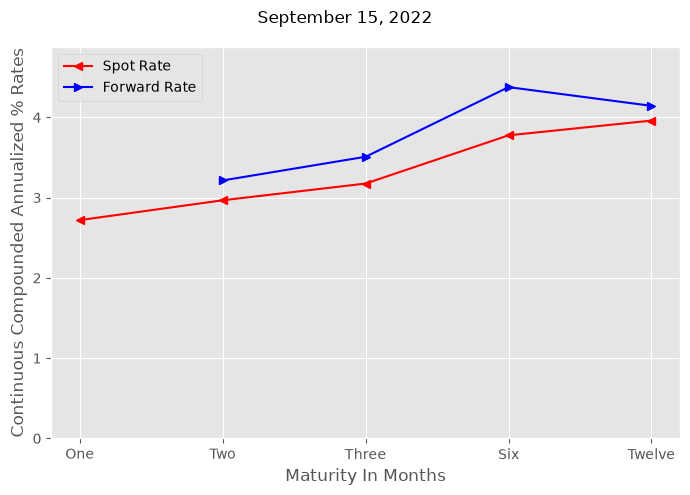

In [13]:
save_config=dict(file_name='Term Structure September 15 2022.pdf',
                 volume='Basic Concepts Fixed Income',
                 chapter= 'One')
# Define the labels for the x-axis, representing different maturities.
xaxis = ['One', 'Two', 'Three', 'Six', 'Twelve']

# Define the specific date for which the term structure will be plotted.
string_date = '09/15/2022'

# Get the integer location (row index) of the specified 'string_date' in the DataFrame's index..
loc = Tbill_data_excel.index.get_indexer([string_date])[0]

# Prepare the data to be plotted on the y-axis (as %).
data = [spot_rates[loc]*100, forward_rates[loc]*100]

# Attempt to extract the plot title from the file name.
try:
    title = os.path.splitext(save_config['file_name'])[0]
#'file_name key not found set a default title.
except:
    title = 'September 15, 2022'

# Define the names for the data series that will appear in the plot's legend.
series = ['Spot Rate', 'Forward Rate']

# Define the label for the y-axis.
ylabel = 'Continuous Compounded Annualized % Rates'

# Define the label for the x-axis.
xlabel = 'Maturity In Months'

#'data' contains two series (spot and forward rates).
x = len(data)

# Define markers for the plot.
markers = ['<','>']*round(x/2+x%2+0.001)

# Define the lower bound for the y-axis.
lower = 0

# Define the upper bound for the y-axis.
# considering NaN values (not a number) and adds a small buffer (0.5) for padding.
upper = max(np.nanmax(data[0]), np.nanmax(data[1])) + 0.5

# Define the y-axis limits (minimum and maximum values).
ylim = [lower, upper]

# Define the size of the plot (width, height) in inches.
size = (7, 5)
# Define colors as red and blue
colors=['r','b']
# This function generates and possibly saves a plot.
fq.one_y_axis(xaxis, data, title=title, series_labels=series, xlabel=xlabel,
              y_limits=ylim,ylabel=ylabel, markers=markers,colors=colors,
              figure_size=size)

## 🌐 * 📁 * Accessing T-Bill Data Directly from the Treasury

**Figure 1** shows a screenshot of the Treasury page and its data tool, [found here](https://home.treasury.gov/resource-center/data-chart-center/interest-rates/TextView?type=daily_treasury_bill_rates). The time period selected determines the URL for the “Download CSV” link. In our example, the year is set to 2025 and the month is September. As we will see below, the URL includes the string of a four-digit year and a two-digit month (`'202509'`).




#### The link to the [Daily Treasury Bill Rates on the Treasury Site](https://home.treasury.gov/resource-center/data-chart-center/interest-rates/TextView?type=daily_treasury_bill_rates)
<br>

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Figure 1. Accessing T-bill rates

<img  src='https://github.com/PatrickJHess/Volume-Three-Chapter-One/blob/master/colab/Daily_Treasury_Bill%20Rates_Page.png?raw=1'></img>

Source: "Daily Treasury Bill Rates," US Department of the Treasury, 2025 (accessed Sept. 24, 2025)</img>



## ⚙️ Changing the URL and using the 🐼 Pandas method `read_csv`

The data is accessed directly from the Treasury as a CSV file, and the code below displays the data row for September 30, 2025. With the exception of the URL value and the `read_csv()` versus `read_excel()` methods, the code is identical to what we used to create `Tbill_data_excel`. In this example, the URL points to a Treasury site instead of Dropbox. The URL is copied by right-clicking the “Download CSV” link on the Treasury website. The URL for a particular year and month is shown below, and `data_date` is assigned the string `'202509'`. You can assign it any year and month after 2022.

```
data_date='202509'
url='https://home.treasury.gov/resource-center/data-chart-center/\
interest-rates/daily-treasury-rates.csv/all/'+data_date+'?\
type=daily_treasury_bill_rates&field_tdr_date_value_month=+'data_date'+&page&_format=csv'
```
The CSV file is in descending order of the dates. The first row is for September 30 and is displayed with `iloc[0]`.



---


$^{9}$As of November 3, 2025, dates prior to 2022 will be moved to a historical page, according to the Treasury. See [US Treasury Data Chart Center](https://home.treasury.gov/resource-center/data-chart-center/interest-rates/TextView?type=daily_treasury_bill_rates&field_tdr_date_value=2025).



In [16]:
#Read the csv file from the U.S. Treasury website
#Construct the full file path.
data_date='202509'
url='https://home.treasury.gov/resource-center/data-chart-center/\
interest-rates/daily-treasury-rates.csv/all/'+data_date+'?\
type=daily_treasury_bill_rates&field_tdr_date_value_month='+data_date+'&page&_format=csv'
print(f"Attempting to load data from {url}")

#Load the data from csv, using the Date column as the index.
try:
    Tbill_data_site = pd.read_csv(url,index_col='Date')
    # display September 30, 2025 data
    display(Tbill_data_site.iloc[0])

except FileNotFoundError:
    display("\nERROR: File not found.")
    display("Please check that the 'URL' address")

Attempting to load data from https://home.treasury.gov/resource-center/data-chart-center/interest-rates/daily-treasury-rates.csv/all/202509?type=daily_treasury_bill_rates&field_tdr_date_value_month=202509&page&_format=csv


4 WEEKS BANK DISCOUNT         4.05
4 WEEKS COUPON EQUIVALENT     4.12
6 WEEKS BANK DISCOUNT         4.02
6 WEEKS COUPON EQUIVALENT     4.10
8 WEEKS BANK DISCOUNT         4.00
8 WEEKS COUPON EQUIVALENT     4.08
13 WEEKS BANK DISCOUNT        3.86
13 WEEKS COUPON EQUIVALENT    3.95
17 WEEKS BANK DISCOUNT        3.83
17 WEEKS COUPON EQUIVALENT    3.93
26 WEEKS BANK DISCOUNT        3.72
26 WEEKS COUPON EQUIVALENT    3.84
52 WEEKS BANK DISCOUNT        3.53
52 WEEKS COUPON EQUIVALENT    3.68
Name: 09/30/2025, dtype: float64

For this date, the U.S. Treasury returns T-Bill rates for seven dates.  In September of 2022, rates are returned for five dates.


## <font color="#283593">✍️ **Application:** Download Treasury Data</font>

**The Challenge:** Get data for September 12, 2024 from the U.S. Treasury site.

*Recall:* The url includes a string for the date.

**Goal**: This demonstrates accessing data from an external URL.

---

<details>
<summary style="cursor: pointer; font-size: 1.2em;"><b>🛟 Need hints or a solution?</b></summary>

<details style="margin-left: 20px; margin-top: 15px;">
<summary style="cursor: pointer; font-size: 1.1em;">📄 <b>View Hints</b></summary>

* Determine the `url` by changing the date from `202509` to `202409`.
* Use the Pandas method `read_csv`.
* Make the `'Date'`column the index.
* Use the `loc` method to display September 12 2024 data.

</details>

<details style="margin-left: 20px; margin-top: 15px; margin-bottom: 15px;">
<summary style="cursor: pointer; font-size: 1.1em;">✅ <b>View a Solution</b></summary>

**Example of Code**

```python
import pandas as pd

# the new year and month
data_date='202409'

# url now includes the new year and month
url='[https://home.treasury.gov/resource-center/data-chart-center/](https://home.treasury.gov/resource-center/data-chart-center/)\
interest-rates/daily-treasury-rates.csv/all/'+data_date+'?\
type=daily_treasury_bill_rates&field_tdr_date_value_month='+data_date+'&page&_format=csv'

# read_csv and 'Date' column made the index
Tbill_data_site = pd.read_csv(url,index_col='Date')
df_application = pd.read_csv(url,index_col='Date')

# loc uses to select the desired date of the month
display(df_application.loc['09/12/2024'])

## 𝄜 Using the CSV file to calculate term structure

The following sections proceed much the same as our earlier process for calculating the term structure and thus need little explanation. We’ll convert banks’ discounts to zero prices, calculate spot and forward rates, and prepare the Notebook for graphing the term structure.


In [17]:
# Create a list called 'desired_columns' using a list comprehension.
desired_columns = [column for column in Tbill_data_site.columns if 'BANK' in column]

# Create a DataFrame named 'df_bankers_discount'.
df_bankers_discount = Tbill_data_site[desired_columns]

# Display the first 5 rows of the newly created 'df_bankers_discount' DataFrame.
df_bankers_discount[:5]

,4 WEEKS BANK DISCOUNT,6 WEEKS BANK DISCOUNT,8 WEEKS BANK DISCOUNT,13 WEEKS BANK DISCOUNT,17 WEEKS BANK DISCOUNT,26 WEEKS BANK DISCOUNT,52 WEEKS BANK DISCOUNT
Date,,,,,,,
09/30/2025,4.05,4.02,4.00,3.86,3.83,3.72,3.53
09/29/2025,4.06,4.03,4.00,3.86,3.83,3.73,3.52
09/26/2025,4.07,4.03,4.00,3.87,3.83,3.74,3.53
09/25/2025,4.08,4.03,4.01,3.89,3.84,3.75,3.54
09/24/2025,4.02,4.02,3.98,3.87,3.81,3.72,3.49


In [18]:
# The .to_numpy() method strips away the pandas Index and column headers,
# leaving only the raw data values in a highly efficient array format.
bankers_discount=df_bankers_discount.to_numpy()

# --- Verification Step: Display the First 5 Rows of the New Array ---
# After a data type conversion, it is good practice to inspect the result.
bankers_discount[:5]

array([[4.05, 4.02, 4.  , 3.86, 3.83, 3.72, 3.53],
       [4.06, 4.03, 4.  , 3.86, 3.83, 3.73, 3.52],
       [4.07, 4.03, 4.  , 3.87, 3.83, 3.74, 3.53],
       [4.08, 4.03, 4.01, 3.89, 3.84, 3.75, 3.54],
       [4.02, 4.02, 3.98, 3.87, 3.81, 3.72, 3.49]])

### ≫ Going from bankers’ discounts to zero prices

In [19]:
maturity_days=np.array([4*7,6*7,8*7,13*7,17*7,26*7,52*7]) #Maturity in days calculated
#The price formula divides maturity days by 360 to annualize
#Then divides by 100 to convert to a bill paying one dollar.
zero_prices_one=(100-bankers_discount*maturity_days/360)/100
#NumPy performs element by element calculations: a calculation for each
#value of maturity_days with the corresponding value of bankers_discount
zero_prices_one[:5]   #Display first 5 rows (each row is a trading day for Sept 2025)

array([[0.99685   , 0.99531   , 0.99377778, 0.99024278, 0.98733972,
        0.98119333, 0.96430778],
       [0.99684222, 0.99529833, 0.99377778, 0.99024278, 0.98733972,
        0.98114278, 0.96440889],
       [0.99683444, 0.99529833, 0.99377778, 0.9902175 , 0.98733972,
        0.98109222, 0.96430778],
       [0.99682667, 0.99529833, 0.99376222, 0.99016694, 0.98730667,
        0.98104167, 0.96420667],
       [0.99687333, 0.99531   , 0.99380889, 0.9902175 , 0.98740583,
        0.98119333, 0.96471222]])

### 📍 Spot rates

In [20]:
spot_rates=-np.log(zero_prices_one)/(maturity_days/365) #Maturity_days divided by 365
spot_rates[:5] #Display first 5 rows (last 5 trading days of Sept 2025)

array([[0.04112731, 0.04085421, 0.04068225, 0.03932829, 0.03907985,
        0.03807584, 0.03644461],
       [0.04122902, 0.04095608, 0.04068225, 0.03932829, 0.03907985,
        0.03817917, 0.03633948],
       [0.04133073, 0.04095608, 0.04068225, 0.03943068, 0.03907985,
        0.03828251, 0.03644461],
       [0.04143244, 0.04095608, 0.04078428, 0.03963547, 0.03918254,
        0.03838586, 0.03654976],
       [0.04082219, 0.04085421, 0.04047821, 0.03943068, 0.03887448,
        0.03807584, 0.03602413]])

### ↻ ◁ || ▷ Forward rates

In [21]:
forward_rates=-np.diff(np.log(zero_prices_one))*365/np.diff(maturity_days) #Sign switched
forward_rates=np.insert(forward_rates,0,np.nan,axis=1) #NumPy nan inserted for first month
forward_rates[:5]

array([[       nan, 0.04030802, 0.04016638, 0.03716195, 0.03827242,
        0.03617937, 0.03481338],
       [       nan, 0.0404102 , 0.03986078, 0.03716195, 0.03827242,
        0.0364779 , 0.03449978],
       [       nan, 0.04020678, 0.03986078, 0.03742816, 0.03793965,
        0.03677644, 0.03460671],
       [       nan, 0.04000335, 0.04026888, 0.03779737, 0.03771053,
        0.03688102, 0.03471366],
       [       nan, 0.04091826, 0.03935021, 0.03775464, 0.03706682,
        0.0365673 , 0.03397243]])


## 📈📉 Graphing the Term Structure (Again)






In [22]:
save_config=dict(file_name='Term Structure September 30 2025.pdf',
                 volume='Basic Concepts Fixed Income',
                 chapter= 'One')

## Graphing the spot and forward rates for September 30, 2025
In the following code, the *x*-axis is set at the bills’ seven maturities in months. Forward and spot rates are calculated for the month of September 2025, and the data for September 30, 2025, is plotted.

```
xaxis=['One','One & Half','Two','Three','Four','Six','Twelve']
string_date='09/15/2022'
```
The first row of `spot_rates` and `forward_rates` correspond to September 30. The spot- and forward-rate rows for September 30, 2025, are then multiplied by 100 and assigned to the list `data`.


```
data=[spot_rates[0]*100,forward_rates[0]*100]
```

The plot title is assigned whatever value is assigned to `save_config['File Name']` (minus the PDF extension).

```
try:                    
  title = os.path.splitext(save_config['file_name'])              
except:
  title='September 30, 2025'
```
Series names, labels, and markers are then assigned.

```
series = ['Spot Rate', 'Forward Rate']
ylabel = 'Continuous Compounded Annualized % Rates'
xlabel = 'Maturity In Months'
x = len(data)
markers = ['<','>']*round(x/2+x%2+0.001)
```

The upper limit of the *y*-axis is assigned to `upper` and calculated from the maximum value of the spot and forward rates. As before, the NumPy method `nanmax()` ignores `nan` values. The maximum of `nanmax()` of spot rates (`data[0]`) and forward rates (`data[1]`) plus 0.5% are assigned to `upper `. The lower limit is set to 0, and the size and colors of the lines are once again set as 10 inches wide and 6 inches tall (10,6) and red and blue, respectively.

```
lower = 0
upper = max(np.nanmax(data[0]), np.nanmax(data[1])) + 0.5
ylim = [lower, upper]
size = (7, 5)
colors=['r','b']
```

Finally, the graph is generated and saved with `one_y_axis()`

```
one_y_axis(xaxis, data, title, series, xlabel, ylabel, markers, size, ylim,
           save_config=save_config,colors=colors)
```



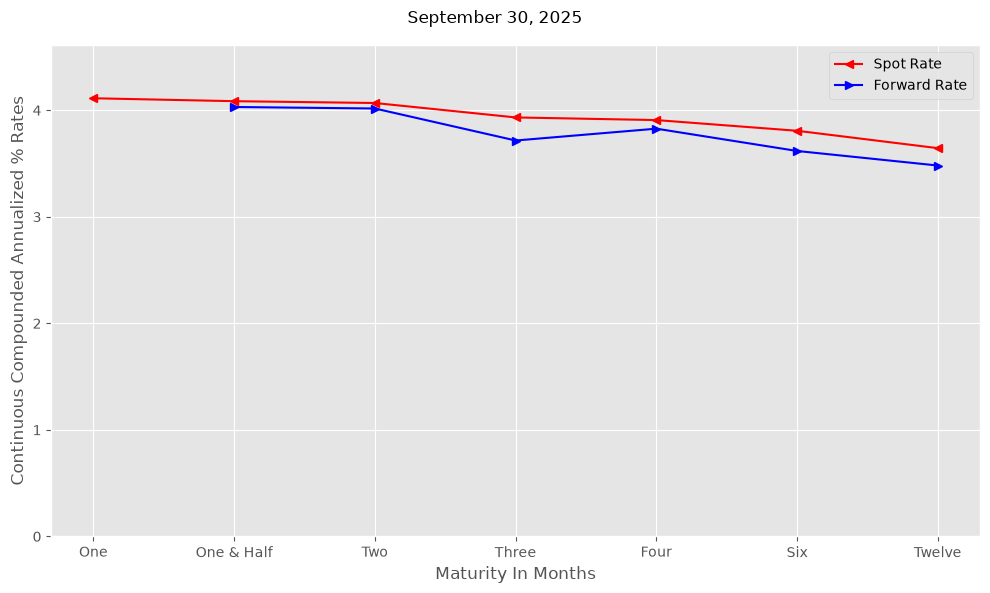

In [23]:
# Define the labels for the x-axis, representing different maturities.
xaxis = ['One','One & Half', 'Two', 'Three','Four', 'Six', 'Twelve']

# Define the specific date for which the term structure will be plotted.
string_date = '09/30/2025'

# Get the integer location (row index) of the specified 'string_date' in the DataFrame's index..
loc = Tbill_data_site.index.get_indexer([string_date])[0]

# Prepare the data to be plotted on the y-axis (as %).
data = [spot_rates[loc]*100, forward_rates[loc]*100]

# Attempt to extract the plot title from the file name.
try:
    title = os.path.splitext(save_config['file_name'])[0]
#'file_name key not found set a default title.
except:
    title = 'September 30, 2025'

# Define the names for the data series that will appear in the plot's legend.
series = ['Spot Rate', 'Forward Rate']

# Define the label for the y-axis.
ylabel = 'Continuous Compounded Annualized % Rates'

# Define the label for the x-axis.
xlabel = 'Maturity In Months'

#'data' contains two series (spot and forward rates).
x = len(data)

# Define markers for the plot.
markers = ['<','>']*round(x/2+x%2+0.001)

# Define the lower bound for the y-axis.
lower = 0

# Define the upper bound for the y-axis.
# considering NaN values (not a number) and adds a small buffer (0.5) for padding.
upper = max(np.nanmax(data[0]), np.nanmax(data[1])) + 0.5

# Define the y-axis limits (minimum and maximum values).
ylim = [lower, upper]

# Define the size of the plot (width, height) in inches.
size = (7, 5)
# Define colors as red and blue
colors=['r','b']
# This function generates and possibly saves a plot.
fq.one_y_axis(xaxis, data, title=title, series_labels=series, xlabel=xlabel,
              y_limits=ylim,ylabel=ylabel, markers=markers,colors=colors,
              figure_size=size)

## <font color="#283593">✍️ **Chapter Exercise**</font>

**The Challenge:** Using the data from September 12, 2024:

1. Calculate spot and forward rates.
2. Plot the spot and forward rates.

*Recall:* You accessed the data in the previous application and `one_y_axis` has been imported.

**Goal:** Test your understanding of the concepts and manipulation of data.

---

<details>
<summary style="cursor: pointer; font-size: 1.2em;"><b>🛟 Need hints or a solution?</b></summary>

<details style="margin-left: 20px; margin-top: 15px;">
<summary style="cursor: pointer; font-size: 1.1em;">📄 <b>View Hints</b></summary>

* Refer to Preparing Notebook section to identify imports
* Remove Columns Not Including BANK From Tbill DataFrame
* Convert the DataFrame to NumPy array.
* Use bank discount to calculate zero prices (include the 17 week maturity).
* Calculate spot and forward rates and plot with `one_y_axis`.

</details>

<details style="margin-left: 20px; margin-top: 15px; margin-bottom: 15px;">
<summary style="cursor: pointer; font-size: 1.1em;">✅ <b>View a Solution</b></summary>

**Example of Code**

```python
# remove all columns but 'BANK'
desired_columns = [column for column in Tbill_data_site.columns if 'BANK' in column]

# create a new DataFrame
df_bankers_discount = Tbill_data_site[desired_columns]

# make calculations easy convert to numpy array
bankers_discount = df_bankers_discount.to_numpy()

# set maturity date as days
maturity_days = np.array([4*7, 8*7, 13*7, 17*7, 26*7, 52*7])

# calculate zero prices from banker discount
zero_prices_one = (100 - bankers_discount * maturity_days / 360) / 100

# calcualte spot rates from zero prices
spot_rates = -np.log(zero_prices_one) / (maturity_days / 365)

# calculate forward rates from zero prices
forward_rates = -np.diff(np.log(zero_prices_one)) * 365 / np.diff(maturity_days)
forward_rates = np.insert(forward_rates, 0, np.nan, axis=1)

# plot results
save_config = {}
xaxis = ['One', 'Two', 'Three', 'Four', 'Six', 'Twelve']
string_date = '09/12/2024'
loc = Tbill_data_site.index.get_indexer([string_date])[0]
data = [spot_rates[loc]*100, forward_rates[loc]*100]
title = 'Exercise Some Basic Concepts And Term Structure Of Interest Rates'
series = ['Spot Rate', 'Forward Rate']
ylabel = 'Continuous Compounded Annualized % Rates'
xlabel = 'Maturity In Months'
x = len(data)
markers = ['<', '>'] * round(x/2 + x%2 + 0.001)
lower = 0
upper = max(np.nanmax(data[0]), np.nanmax(data[1])) + 0.5
ylim = [lower, upper]
size = (10, 6)
colors = ['r', 'b']
fq.one_y_axis(xaxis, data, title=title, series_labels=series, xlabel=xlabel,
              y_limits=ylim,ylabel=ylabel, markers=markers,colors=colors,
              figure_size=size)
```
</details>

<details open>
<summary><b style="font-size:1.2em; color: #673ab7; cursor: pointer;">✨ AI Study Assistant</b></summary>
<div style="margin-top: 12px; padding: 15px; border-left: 4px solid #673ab7; background-color: #f3e5f5; border-radius: 4px;">

<p>Select a prompt below to open Google AI and explore these concepts further. <em>(Sign in to save your chat history!)</em></p>

<hr style="border: 0; border-top: 1px solid #ce93d8; margin: 15px 0;">

<p>✨ <a href="https://www.google.com/search?udm=50&q=Why+use+Treasury+bills+for+estimating+the+term+structure?" target="_blank" style="color: #4a148c; font-weight: bold; text-decoration: none;">Why use Treasury bills for estimating the term structure? ↗</a></p>

<hr style="border: 0; border-top: 1px solid #ce93d8; margin: 15px 0;">

<p>✨ <a href="https://www.google.com/search?udm=50&q=Why+calculate+forward+rates?" target="_blank" style="color: #4a148c; font-weight: bold; text-decoration: none;">Why calculate forward rates? ↗</a></p>

<hr style="border: 0; border-top: 1px solid #ce93d8; margin: 15px 0;">

<p>✨ <a href="https://www.google.com/search?udm=50&q=Do+higher+forward+rates+imply+expected+increases+in+spot+rates?" target="_blank" style="color: #4a148c; font-weight: bold; text-decoration: none;">Do higher forward rates imply expected increases in spot rates? ↗</a></p>

<hr style="border: 0; border-top: 1px solid #ce93d8; margin: 15px 0;">

<p>✨ <a href="https://www.google.com/search?udm=50&q=Shape+of+term+structure+when+the+FED+is+expected+to+cut+rates?" target="_blank" style="color: #4a148c; font-weight: bold; text-decoration: none;">Shape of term structure when the FED is expected to cut rates? ↗</a></p>

</div>
</details>



<div style="display: flex; flex-wrap: wrap; align-items: center; gap: 15px; margin-bottom: 25px; padding-bottom: 15px; border-bottom: 1px solid #eaeaea;">
  
  <a href="https://colab.research.google.com/github/PatrickJHess/Volume-Three-Chapter-One/blob/master/colab/Colab_Calculating_And_Graphing_The_Term_Structure_Of_Interest_Rates.ipynb" target="_blank" style="display: flex; align-items: center;">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" style="height: 28px; margin: 0;">
  </a>
&emsp;
  <a href="https://mybinder.org/v2/gh/PatrickJHess/Volume-Three-Chapter-One/master?urlpath=lab/tree/notebooks/Calculating_And_Graphing_The_Term_Structure_Of_Interest_Rates.ipynb" target="_blank" style="background-color: #f5a252; color: white; padding: 0 12px; text-decoration: none; font-weight: bold; border-radius: 4px; font-family: sans-serif; display: flex; align-items: center; font-size: 0.9em; height: 28px; box-sizing: border-box;">
    <span style="margin-right: 6px; font-size: 1.1em;">🚀</span> Launch Live in Binder
  </a>
&emsp;
  <a href="https://patrickjhess.github.io/Volume-Three-Chapter-One/" style="background-color: #f1f3f4; color: #3c4043; border: 1px solid #dadce0; padding: 0 12px; text-decoration: none; font-weight: bold; border-radius: 4px; font-family: sans-serif; display: flex; align-items: center; font-size: 0.9em; height: 28px; box-sizing: border-box;">
    <span style="margin-right: 6px; font-size: 1.1em;">⬅️</span> Return to Main Book
  </a>

</div>